# Summarizing FINAL results for the 3 models

This is the notebook where the final training and evaluation metrics were aggregated and plotted for **Figure 7** in the [preprint](https://doi.org/10.64898/2025.12.19.694709). This notebook includes a version of the same code used in [results_plotting_aggregation_CV.ipynb](results_plotting_aggregation_CV.ipynb) to aggregate and plot the cross-validation data. Again, this notebook is provided as-is as a record of the work, but it is rough and some snippets are more important than others. Again, this notebook is provided "as-is" as a record of the work, but it is rough and some snippets are more important than others.

In [1]:
import pandas as pd
import numpy as np
import ast
import os
import re

class ResultsSet:
    """Parses, holds, and plots the results from training/testing run(s)."""
    
    def __init__(self, 
                 directories: list,
                 run_type: str = None):
        
        if run_type == 'final':
            for dir in directories:
                logs = [ file for file in os.listdir(dir) if 'log_complete.csv' in file ]
                if logs:
                    log = logs[0]
                    os.rename(f'{dir}{log}', f'{dir}{log.replace("log_complete.csv", "log_fold_1_complete.csv")}')
        
        self.directories, self.n_finished, self.example_log, self.base_names = self.__count_complete(directories)
        self.best_epochs = {}
        self.summaries = {}
        self.__prepare_data()

    def __count_complete(self, directories):
        """Checks provided directories for complete logs."""
        expr = re.compile(r'_(\d*)_complete')
        n_complete = []
        first_logs = []
        full_dirs = []
        for dir in directories:
            logs = [ file for file in os.listdir(dir) if 'complete.csv' in file ]
            if logs:
                final = max([ int(re.search(expr, log).group(1)) for log in logs ])
                n_complete.append(final)
                first_logs.append(logs[0])
                full_dirs.append(dir)
            else:
                print(f'No log files found in {dir}, ignoring.')
        base_names = [log.split('_')[0] for log in first_logs]
        return full_dirs, n_complete, first_logs, base_names
    
    def __prepare_data(self):
        """"Iterates through the provided (non-empty) directories and compiles summary statistics from the best epoch(s)."""
        for i, dir in enumerate(self.directories):
            single_flag = self.n_finished[i] == 1
            packed_unpacked = self.__find_packed(f'{dir}{self.example_log[i]}')
            self.best_epochs[self.base_names[i]], self.summaries[self.base_names[i]] = self.__get_summary_df(base_path=f'{dir}{self.base_names[i]}', N_folds=self.n_finished[i], single=single_flag, **packed_unpacked)
            self.best_epochs[self.base_names[i]] = self.restructure_F1(df=self.best_epochs[self.base_names[i]], suffixes=['', ''])
            if self.summaries[self.base_names[i]] is not None:
                self.summaries[self.base_names[i]] = self.restructure_F1(df=self.summaries[self.base_names[i]])
    
    def __find_packed(self, path: str) -> pd.DataFrame:
        """Reads the CSV and puts all columns into a usable form"""
        training_log = pd.read_csv(path)
        packed = [column for column in training_log.columns if training_log[column].dtype == 'object']
        unpacked = list(set(training_log.columns).difference(set(packed)))
        return {'packed' : packed, 'unpacked' : unpacked}
    
    def __unpack_tf_col(self, df: pd.DataFrame, cols: list) -> pd.DataFrame:
        """"arses columns that were serialized as a string representation of a tf tensor"""
        expr = re.compile(r'tf.Tensor\((\d*\.\d*e?-?\d*),')
        for col in cols:
            column = df[col]
            for i in range(df.shape[0]):
                row = ast.literal_eval(column[i])
                found = []
                for match in expr.finditer(row):
                    found.append(float(match.group(1)))
                df.at[i, col] = found
        return df

    def __import_parse_log(self, path: str, packed: list, unpacked: list = None) -> pd.DataFrame:
        """Reads the CSV and puts all columns into a usable form"""
        training_log = pd.read_csv(path)
        return self.__unpack_tf_col(training_log, cols=packed)

    def __aggregate_best(self, dfs_list: list) -> pd.DataFrame:
        """Grabs the row from each data frame corresponding to the best epoch"""
        best_metric: str = 'val_loss'
        best_list = []
        for i, df in enumerate(dfs_list):
            best_list.append(df[df[best_metric]==df[best_metric].min()])
        best_df = pd.concat(best_list)
        best_df.index = [(i + 1) for i in range(len(best_list))]
        best_df.epoch = best_df.epoch + 1
        return best_df

    def __summary_stats(self, aggregated_results_df: pd.DataFrame, unpacked: list, packed: list) -> pd.DataFrame:
        """Computes the mean and standard error across the best epochs for each metric (packed or unpacked)"""
        
        unpacked = [item for item in unpacked if item != 'epoch']
        sem_suffix = '_SEM'
        mean_suffix = '_mean'
        colz = []
        for col in unpacked + packed:
            for suffix in [mean_suffix, sem_suffix]:
                colz.append(f'{col}{suffix}')
        new_df = pd.DataFrame(columns=colz, index=[0])
        
        for col in unpacked + packed:
            if col in packed:
                aggregated = np.array([row for row in aggregated_results_df[col]])
                
                if 'val_Precision_Exon-Intron' in col: # Sometimes keras metrics don't handle limits well, particularly for precision and recall
                    for i in range(aggregated.shape[0]):
                        if aggregated[i,-1] == 0.0 and aggregated[i,-2] == 1.0:
                            aggregated[i,-1] = np.nan
                mean = np.nanmean(aggregated, axis=0)
                sem = np.nanstd(aggregated, axis=0) / np.sqrt(aggregated.shape[0])
            else:
                mean = aggregated_results_df[col].mean()
                sem = aggregated_results_df[col].std() / np.sqrt(len(aggregated_results_df[col]))
            new_df.loc[0, f'{col}{mean_suffix}'] = mean
            new_df.loc[0, f'{col}{sem_suffix}'] = sem
        
        return new_df

    def __get_summary_df(self, base_path: str, N_folds: int, single: bool, **kwargs) -> pd.DataFrame:
        """Calls the functions above for the run logs ina specified directory and aggregates summary of metrics for best epochs."""
        best_epoch_results = self.__aggregate_best([self.__import_parse_log(base_path + f'_log_fold_{i+1}_complete.csv', **kwargs) for i in range(N_folds)])
        if single:
            return best_epoch_results, None
        else:
            return best_epoch_results, self.__summary_stats(best_epoch_results, **kwargs)
    
    def restructure_F1(self, df, suffixes: list = ['_mean', '_SEM']):
        """F1 score was computer per-class at different thresholds, these results need to be restructured for easier access."""
        classes = ['Control', 'Intron-Exon', 'Exon-Intron']
        prefixes = ['', 'val_']
        new_cols = []
        for cls in classes:
            for prefix in prefixes:
                for suffix in suffixes:
                    new_cols.append(f'{prefix}F1_Score_{cls}{suffix}')
        columns = df.filter(like='F1_Score_0')
        new_cols = list(set(new_cols))
        expr = re.compile(r'_(0\.\d)')
        thresholds = sorted(set([float(re.search(expr, column).group(1)) for column in columns.columns]))
        
        for col in new_cols + ['F1_thresholds']:
            new_series = pd.Series([], dtype='object')
            df[col] = new_series
        
        for j in df.index:
            
            restructured = {col : [] for col in new_cols}
            for threshold in thresholds:
                for i, cls in enumerate(classes):
                    for prefix in prefixes:
                        if suffixes[0] and suffixes[1]:
                            for suffix in suffixes:
                                restructured[f'{prefix}F1_Score_{cls}{suffix}'].append(float(df[f'F1_Score_{threshold}{suffix}'][j][i]))
                        else:
                            restructured[f'{prefix}F1_Score_{cls}'].append(float(df[f'F1_Score_{threshold}'][j][i]))
            
            for key in restructured:
                df.at[j, key] = restructured[key]
            
            df.at[j, 'F1_thresholds'] = thresholds
        
        old_cols = df.filter(regex='F1_Score_0\.\d*[_mean|_SEM]*').columns
        df = df.drop(columns=old_cols)
        return df

# dirs = ['./TCN_best_cv/', './BiLSTM_best_cv/', './MBDA-Net_best_cv/']
# results = ResultsSet(dirs)

final_dirs = ['./TCN_final/', './BiLSTM_final/', './MBDA-Net_final/']
final_results = ResultsSet(final_dirs, run_type='final')

In [5]:
final_results.best_epochs['MBDA-Net'].filter(like='F1')

,F1_Score_argmax,val_F1_Score_argmax,val_F1_Score_Exon-Intron,F1_Score_Intron-Exon,val_F1_Score_Intron-Exon,F1_Score_Exon-Intron,F1_Score_Control,val_F1_Score_Control,F1_thresholds
1,"[0.9912472, 0.81537426, 0.82904744]","[0.9920986, 0.8663716, 0.8152488]","[0.88556564, 0.8818056, 0.8682502, 0.8512163, ...","[0.878106, 0.875493, 0.8609618, 0.841123, 0.81...","[0.878106, 0.875493, 0.8609618, 0.841123, 0.81...","[0.88556564, 0.8818056, 0.8682502, 0.8512163, ...","[0.98222846, 0.98618424, 0.9884882, 0.99007326...","[0.98222846, 0.98618424, 0.9884882, 0.99007326...","[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]"


# Plotting the test performance

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from get_normalization_params_5 import load_json
from preparation_1 import structural_profiles


def plot_AUC_curves(compare_list, 
                      names: list, 
                      plot_title: str,
                      class_counts: dict,
                      show_thresholds: list,
                      threshold_interval: float = 0.1,
                      thresholds_to_show: list = [None, None, None],
                      threshold_cutoff: float = 1e-15,
                      curve_type: str = 'PR',
                      colors: list = ['indianred', 'forestgreen', 'darkblue'], 
                      CI_crit: float = 1.960,
                      CI_alpha: float = 0.3,
                      omit_CI_classes: list = ['Control'],
                      omit_threshold_classes: list = ['Control'],
                      showCI: list = [False, False, False],
                      lock_axes: list = [True, True],
                      single_run: list = [False, False, False],
                      figure_dims: tuple = (12, 3),
                      legend_pos: str = 'best',
                      linestyles: list = ['solid', 'dashed', 'dotted'],
                      ylims: list = [None]*3,
                      xlims: list = [None]*3,
                      lw: int = 2):
    
    if curve_type == 'PR':
        y_metric = "Precision"
        x_metric = "Recall"
        y_label = y_metric
        x_label = f'{x_metric}'
    elif curve_type == 'ROC':
        y_metric = "Recall"
        x_metric = "FPR"
        y_label = f'{y_metric} (TPR)'
        x_label = f'FPR'
    elif curve_type == 'F1':
        y_metric = "F1_Score"
        x_metric = "F1_thresholds"
        y_label = y_metric.replace('_', ' ')
        x_label = f'Decision threshold'
    else:
        print('plot_AUC_curves(): Invalid curve type selected and/or necessary parameters not provided!')
        return None
    
    classes = ['Intron-Exon', 'Exon-Intron', 'Control']
    fig, (ax1, ax2, ax3) = plt.subplots(1, len(classes), figsize=figure_dims, sharey=lock_axes[1], sharex=lock_axes[0])
    axes = (ax1, ax2, ax3)
    fig.suptitle(plot_title, fontsize="large", fontweight="bold")
    
    for i, cls in enumerate(classes):
        
        if ylims[i] is not None:
            ax1.set_ylim(ylims[i])
        if xlims[i] is not None:
            ax1.set_xlim(xlims[i])
        
        for j, summary_data in enumerate(compare_list):
            
            # Is there full N-fold cross-validation data for this model? If not just plot the one run provided.
            suffix = "_mean" if not single_run[j] else ""
            if curve_type == 'F1':
                x = np.array(summary_data[x_metric])[0]
            else:
                x = np.array(summary_data[f'val_{x_metric}_{cls}{suffix}'])[0]
            y = np.array(summary_data[f'val_{y_metric}_{cls}{suffix}'])[0]
            axes[i].plot(x, y, color=colors[j], label=names[j], linestyle=linestyles[j], linewidth=lw)
            
            # Plots the confidence interval as a shaded region around the mean
            if showCI[j] and cls not in omit_CI_classes and not single_run[j]:
                
                y_err = np.array(summary_data[f'val_{y_metric}_{cls}_SEM'])[0]
                
                if curve_type == 'F1':
                    
                    y1 = np.array(y) - CI_crit*np.array(y_err)
                    y2 = np.array(y) + CI_crit*np.array(y_err)
                    axes[i].fill_between(x, y1, y2, color=colors[j], alpha=CI_alpha)
                    
                else:
                    x_err = np.array(summary_data[f'val_{x_metric}_{cls}_SEM'])[0]

                    # Calculate the means plus or minus the confidence interval
                    x1 = np.array(x) - CI_crit*np.array(x_err)
                    y1 = np.array(y) - CI_crit*np.array(y_err)
                    x2 = np.array(x) + CI_crit*np.array(x_err)
                    y2 = np.array(y) + CI_crit*np.array(y_err)
                    
                    # Combine and sort the x-values to create a common x-axis
                    x_common = np.sort(np.concatenate([x1, x2]))

                    if curve_type == 'PR':
                        # Interpolate the y-values from each line onto the common x-axis
                        y1_interp = np.interp(np.flip(x_common), np.flip(x1), np.flip(y1))
                        y2_interp = np.interp(np.flip(x_common), np.flip(x2), np.flip(y2))
                        
                        # Fill the area using the interpolated data
                        axes[i].fill_between(np.flip(x_common), y1_interp, y2_interp, color=colors[j], alpha=CI_alpha)
                    else:
                        axes[i].plot(x1, y1, color=colors[j], label=names[j])
                        axes[i].plot(x2, y2, color=colors[j], label=names[j]) #TODO: fix for ROC
                        # # Interpolate the y-values from each line onto the common x-axis
                        # y1_interp = np.interp(x_common, x1, y1)
                        # y2_interp = np.interp(x_common, x2, y2)
                        
                        # # Fill the area using the interpolated data
                        # axes[i].fill_between(x_common, y1_interp, y2_interp, color=colors[j], alpha=CI_alpha)
            
            # Labels specific points with the decision threshold (criterion used to avoid showing all/visual clutter)
            if show_thresholds[j] and cls not in omit_threshold_classes and curve_type != 'F1':
                if thresholds_to_show[i] is not None:
                    combined_mask = np.zeros((len(thresholds),), dtype=bool)
                    for threshold in thresholds_to_show[i]:
                        mask = np.isclose(np.array(thresholds), threshold)
                        combined_mask = combined_mask | mask
                    chosen_thresh = np.where(combined_mask)[0]
                    
                else:
                    chosen_thresh = np.argwhere([np.array(thresholds) % threshold_interval < threshold_cutoff])[:,1]
                for k in chosen_thresh:
                    text = str(round(thresholds[k], 2))
                    axes[i].text(x[k], y[k], text)
        
        # Finalize details of the plot, like subplot titles and axis titles
        axes[i].set_title(f'{cls} (N={int(class_counts[cls]):,})', fontweight="bold")
        if i == 0:
            axes[i].set_ylabel(y_label, fontsize="large", fontweight="bold")
        if i == 2:
            axes[i].legend(loc=legend_pos)
        axes[i].set_xlabel(x_label, fontsize="large", fontweight="bold")
        axes[i].grid()
    plt.tight_layout()

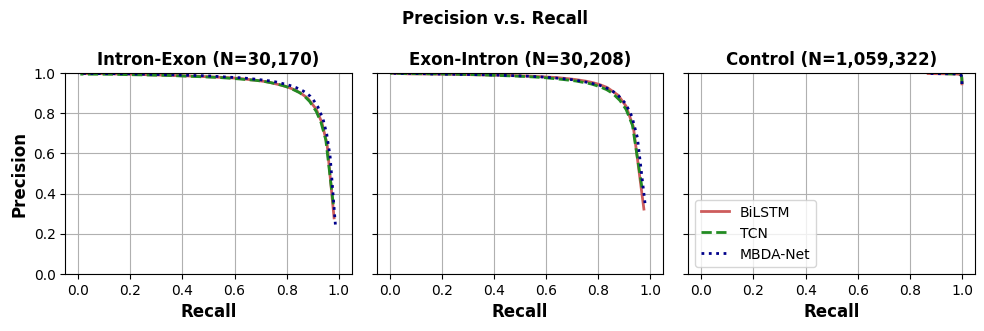

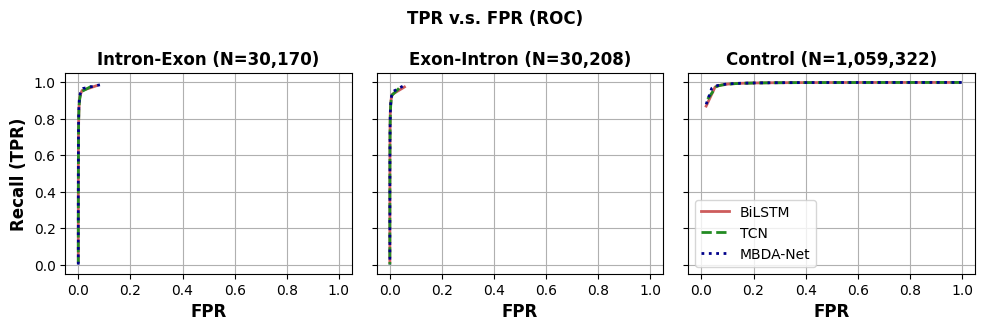

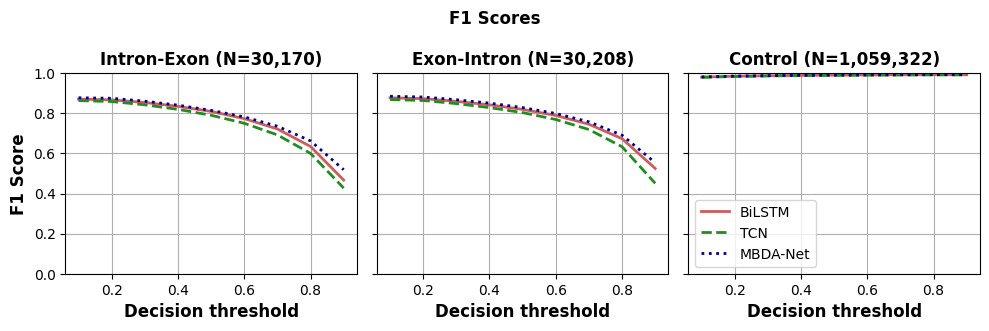

In [3]:
counts = load_json(f'{structural_profiles}class_counts.json')
class_counts = {}
proportion_of_training = 5/4 * 1/5
class_counts['Control'] = int((counts['control_introns_intergenic'] + counts['control_introns_intron'] + counts['control_exons']) * proportion_of_training)
class_counts['Intron-Exon'] = int(counts['intron-exon'] * proportion_of_training)
class_counts['Exon-Intron'] = int(counts['exon-intron'] * proportion_of_training)
thresholds = [0.001, 0.01, 0.025] + np.arange(0.05, 1.0, 0.05).tolist() + [0.975, 0.98, 0.985, 0.99, 0.999] # Get the whole PR curve

fig_d = (10, 3.33)

plot_AUC_curves([final_results.best_epochs['BiLSTM'], final_results.best_epochs['TCN'], final_results.best_epochs['MBDA-Net']], 
                  ['BiLSTM', 'TCN', 'MBDA-Net'], 
                  curve_type='PR',
                  class_counts=class_counts,
                  showCI=[False, False, False],
                  show_thresholds=[False, False, False],
                  single_run=[True, True, True],
                  lock_axes=[True, True],
                  omit_threshold_classes = ['Control'],
                  thresholds_to_show = [None, None, None],
                  legend_pos='lower left',
                  plot_title='Precision v.s. Recall',
                  figure_dims = fig_d,
                  ylims=[(0,1),(0,1),(0,1)])

plot_AUC_curves([final_results.best_epochs['BiLSTM'], final_results.best_epochs['TCN'], final_results.best_epochs['MBDA-Net']], 
                  ['BiLSTM', 'TCN', 'MBDA-Net'], 
                  curve_type='ROC',
                  class_counts=class_counts,
                  showCI=[False, False, False], #TODO: fix for ROC
                  show_thresholds=[False, False, False],
                  single_run=[True, True, True],
                  lock_axes=[True, True],
                  legend_pos='lower left',
                  omit_threshold_classes = ['Control'],
                  thresholds_to_show = [None, None, None],
                  plot_title='TPR v.s. FPR (ROC)',
                  figure_dims = fig_d)

plot_AUC_curves([final_results.best_epochs['BiLSTM'], final_results.best_epochs['TCN'], final_results.best_epochs['MBDA-Net']], 
                  ['BiLSTM', 'TCN', 'MBDA-Net'],  
                  curve_type='F1',
                  class_counts=class_counts,
                  showCI=[True, True, True],
                  show_thresholds=[False, False, False],
                  single_run=[True, True, True],
                  lock_axes=[True, True],
                  omit_CI_classes=[],
                  omit_threshold_classes = ['Control'],
                  legend_pos='lower left',
                # thresholds_to_show = [None, None, [0.99, 0.8, 0.6, 0.4, 0.2]],
                  plot_title='F1 Scores',
                  figure_dims = fig_d,
                  ylims=[(0,1),(0,1),(0,1)])

## Matplotlib barcharts

In [73]:
import matplotlib.pyplot as plt
import numpy as np



metric = 'val_F1_Score_argmax_mean'
y_label = 'F1 Score (max probability)'
labels = ['TCN (mean ± 95% CI)', 'BiLSTM (mean ± 95% CI)', 'MBDA-Net (single fold)']
title = "Tuning F1 Score (argmax) from cross validation"



def make_mtplt_grouped_bar(
    results,
    metric: str,
    y_label: str,
    labels: list,
    title: str,
    width: float = 0.25,  # the width of the bars
    CI_crit: float = 1.960,
    show_legend: bool = True,
    legend_pos: str = 'best',
    classes_idx = {'Control' : 0, 
                   'Intron-Exon' : 1, 
                   'Exon-Intron' : 2},
    classes = ['Intron-Exon', 'Exon-Intron', 'Control'],
    names = ['TCN', 'BiLSTM', 'MBDA-Net'],
    colors = ['dodgerblue', 'indianred', 'forestgreen'],
    fig_dims: tuple = (5.5, 5)):
    
    x = np.arange(len(classes))  # the label locations
    fig, ax = plt.subplots(layout='constrained', figsize=fig_dims)
    ax.set_axisbelow(True)
    ax.grid()
    multiplier = 0
    
    if 'F1' in metric:
        for i, model in enumerate(names):
            single = results.summaries[model] is None
            offset = width * multiplier
            if not single:
                df = results.summaries[model]
                data = df[metric][df.index[0]]
                data = [data[classes_idx[cls]] for cls in classes ]
                sem = df[metric.replace('_mean', '_SEM')][df.index[0]]
                sem = [ sem[classes_idx[cls]] for cls in classes ]
                rects = ax.bar(x + offset, data, width, label=labels[i], capsize=5, color=colors[i], yerr=CI_crit*np.array(sem))
            else:
                df = results.best_epochs[model]
                data = df[metric.replace('_mean', '')][df.index[0]]
                data = [data[classes_idx[cls]] for cls in classes ]
                rects = ax.bar(x + offset, data, width, label=labels[i], color=colors[i])
            
            ax.bar_label(rects, fmt='{:.2f}', padding=3, label_type='center', color='white', fontweight='bold')
            multiplier += 1
    else:
        for i, model in enumerate(names):
            single = results.summaries[model] is None
            offset = width * multiplier
            if not single:
                df = results.summaries[model]
                data = []
                sem = []
                for cls in classes:
                    data.append(df[f'{metric}_{cls}_mean'][df.index[0]])
                    sem.append(df[f'{metric}_{cls}_SEM'][df.index[0]])
                rects = ax.bar(x + offset, np.array(data), width, label=labels[i], capsize=5, color=colors[i], yerr=CI_crit*np.array(sem))
            else:
                df = results.best_epochs[model]
                data = []
                for cls in classes:
                    data.append(df[f'{metric}_{cls}'][df.index[0]])
                rects = ax.bar(x + offset, np.array(data), width, label=labels[i], color=colors[i])
            
            ax.bar_label(rects, fmt='{:.2f}', padding=3, label_type='center', color='white', fontweight='bold')
            multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(y_label, fontsize="large")
    ax.set_title(title, fontweight="bold")
    ax.set_xticks(x + width, classes)
    ax.tick_params(axis='x', labelsize=12)
    
    if show_legend:
        ax.legend(loc=legend_pos)

    # ax.set_ylim(0, 250)

    plt.show()


# make_mtplt_grouped_bar(
#     results=results,
#     metric = 'val_F1_Score_argmax_mean',
#     y_label = 'F1 Score (max probability)',
#     labels = ['TCN (mean ± 95% CI)', 'BiLSTM (mean ± 95% CI)', 'MBDA-Net (single fold)'],
#     title = "F1 Score (argmax)")

# make_mtplt_grouped_bar(
#     results=results,
#     show_legend=False,
#     legend_pos='lower right',
#     metric = 'val_AUC_ROC',
#     y_label = 'Area under ROC',
#     labels = ['TCN (mean ± 95% CI)', 'BiLSTM (mean ± 95% CI)', 'MBDA-Net (single fold)'],
#     title = "ROC AUC")

# make_mtplt_grouped_bar(
#     results=results,
#     show_legend=False,
#     legend_pos='lower right',
#     metric = 'val_AUC_PR',
#     y_label = 'Area under PR curve',
#     labels = ['TCN (mean ± 95% CI)', 'BiLSTM (mean ± 95% CI)', 'MBDA-Net (single fold)'],
#     title = "PR AUC")

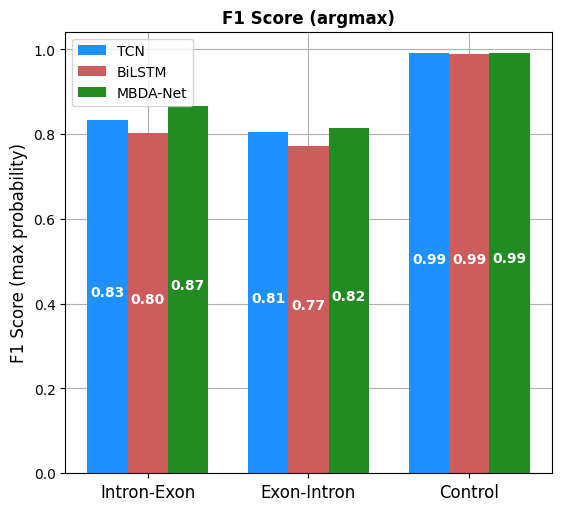

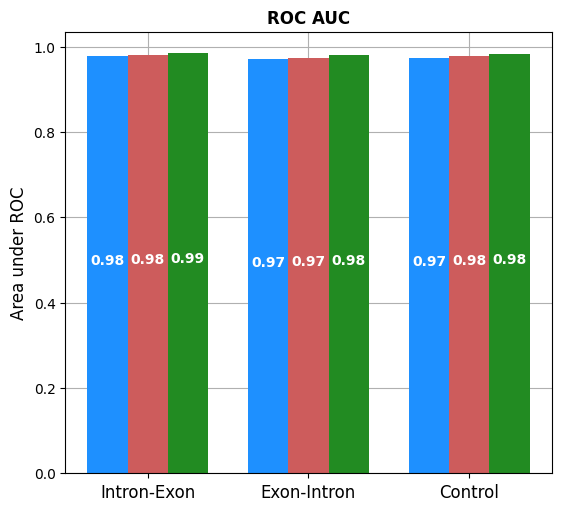

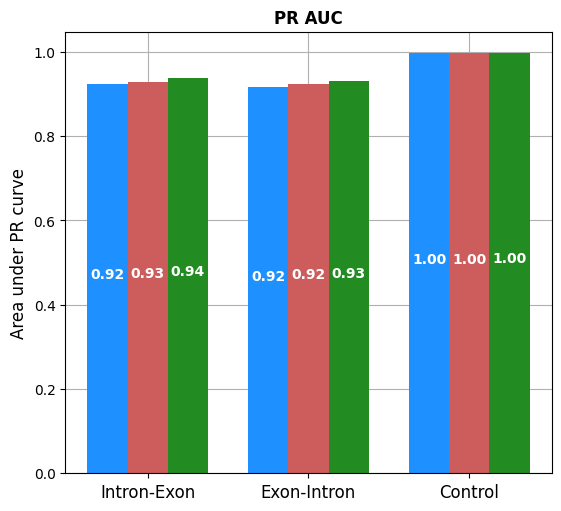

In [74]:
make_mtplt_grouped_bar(
    results=final_results,
    metric = 'val_F1_Score_argmax_mean',
    y_label = 'F1 Score (max probability)',
    labels = ['TCN', 'BiLSTM', 'MBDA-Net'],
    title = "F1 Score (argmax)")

make_mtplt_grouped_bar(
    results=final_results,
    show_legend=False,
    legend_pos='lower right',
    metric = 'val_AUC_ROC',
    y_label = 'Area under ROC',
    labels = ['TCN', 'BiLSTM', 'MBDA-Net'],
    title = "ROC AUC")

make_mtplt_grouped_bar(
    results=final_results,
    show_legend=False,
    legend_pos='lower right',
    metric = 'val_AUC_PR',
    y_label = 'Area under PR curve',
    labels = ['TCN', 'BiLSTM', 'MBDA-Net'],
    title = "PR AUC")